Problem statement: To build a CNN based model which can accurately detect melanoma. Melanoma is a type of cancer that can be deadly if not detected early. It accounts for 75% of skin cancer deaths. A solution which can evaluate images and alert the dermatologists about the presence of melanoma has the potential to reduce a lot of manual effort needed in diagnosis.

### Importing Skin Cancer Data
#### To do: Take necessary actions to read the data

### Importing all the important libraries

In [2]:
from tensorflow.python.client import device_lib
def get_available_devices():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos]
print(get_available_devices()) 


['/device:CPU:0']


In [3]:
import tensorflow as tf
print(tf.__version__, tf.config.list_physical_devices('GPU'))

2.15.1 []


In [4]:
# !pip install matplotlib
# !pip install pandas tensorflow pillow

In [5]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [6]:
## If you are using the data by mounting the google drive, use the following :
## from google.colab import drive
## drive.mount('/content/gdrive')

##Ref:https://towardsdatascience.com/downloading-datasets-into-google-drive-via-google-colab-bcb1b30b0166

This assignment uses a dataset of about 2357 images of skin cancer types. The dataset contains 9 sub-directories in each train and test subdirectories. The 9 sub-directories contains the images of 9 skin cancer types respectively.

In [7]:
# Defining the path for train and test images
## Todo: Update the paths of the train and test dataset
path = 'C:/Users/Joseph/PycharmProjects/upGrad/CNN/MelonnaAssignment/Skin cancer ISIC The International Skin Imaging Collaboration/'
train_path = path+'/Train/'
test_path = path+'/Test/'
data_dir_train = pathlib.Path(train_path)
data_dir_test = pathlib.Path(test_path)

In [8]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

2239
118


### Load using keras.preprocessing

Let's load these images off disk using the helpful image_dataset_from_directory utility.

### Create a dataset

Define some parameters for the loader:

In [11]:
batch_size = 32
img_height = 180
img_width = 180
image_size = (img_height, img_width)


Use 80% of the images for training, and 20% for validation.

In [12]:
## Write your train dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
seed=123

# train_ds = tf.keras.preprocessing.image_dataset_from_directory(train_path, image_size=(img_height, img_width), seed=seed)
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.1,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int'
)

Found 11239 files belonging to 9 classes.
Using 10116 files for training.
Using 1123 files for validation.


In [13]:
## Write your validation dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(test_path, image_size=(img_height, img_width), seed=123)

Found 118 files belonging to 9 classes.


In [14]:
# List out all the classes of skin cancer and store them in a list. 
# You can find the class names in the class_names attribute on these datasets. 
# These correspond to the directory names in alphabetical order.
class_names = train_ds.class_names
print(class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


### Visualize the data
#### Todo, create a code to visualize one instance of all the nine classes present in the dataset

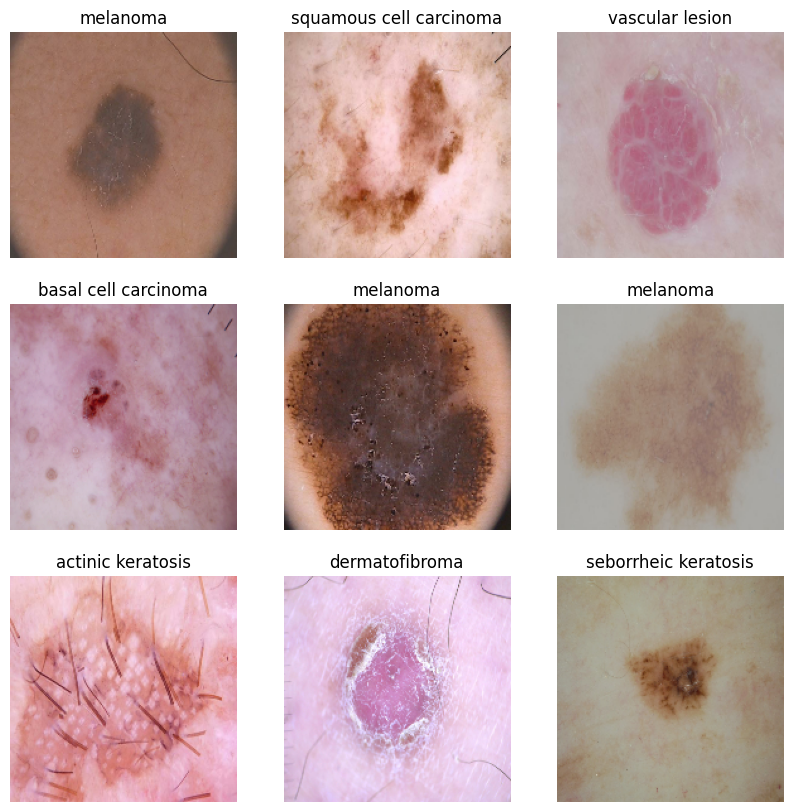

In [15]:
import matplotlib.pyplot as plt

image_batch, label_batch = next(iter(train_ds))  # Get the first batch

# Plot 9 images (3 rows x 3 columns)
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[label_batch[i].numpy()])
    plt.axis('off')
plt.show()

The `image_batch` is a tensor of the shape `(32, 180, 180, 3)`. This is a batch of 32 images of shape `180x180x3` (the last dimension refers to color channels RGB). The `label_batch` is a tensor of the shape `(32,)`, these are corresponding labels to the 32 images.

`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.

`Dataset.prefetch()` overlaps data preprocessing and model execution while training.

In [16]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Create the model
#### Todo: Create a CNN model, which can accurately detect 9 classes present in the dataset. Use ```layers.experimental.preprocessing.Rescaling``` to normalize pixel values between (0,1). The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network. Here, it is good to standardize values to be in the `[0, 1]`

In [49]:
## Apply Rescaling
normalization_layer = tf.keras.layers.experimental.preprocessing.Rescaling(1./255)
final_train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
# final_train_ds = next(iter(normalized_training_set))

final_val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
# final_val_ds = next(iter(normalized_training_set))


# inputs = keras.Input(shape=input_shape)
# x = data_augmentation(inputs)
# x = layers.experimental.preprocessing.Rescaling(1./255)(x)

In [18]:
image_size + (3,)

(180, 180, 3)

In [19]:
### Your code goes here
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

input_shape = (img_height, img_width, 3)
num_classes = len(class_names)

model = Sequential()

# model.add(layers.experimental.preprocessing.Rescaling(1.0 / 255))
# model.add(layers.InputLayer(input_shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape)) # input shape = (img_rows, img_cols, 1)

# second conv layer
model.add(Conv2D(64, kernel_size=(3, 3), 
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# second conv layer
# model.add(Conv2D(128, kernel_size=(3, 3), 
#                  activation='relu'))

# flatten and put a fully connected layer
model.add(Flatten())
model.add(Dense(128, activation='relu')) # fully connected
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu')) # fully connected

# softmax layer
model.add(Dense(num_classes, activation='softmax'))

# model summary
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 176, 176, 64)      18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 88, 88, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 88, 88, 64)        0         
                                                                 
 flatten (Flatten)           (None, 495616)            0         
                                                                 
 dense (Dense)               (None, 128)               63438976  
                                                       

### Compile the model
Choose an appropirate optimiser and loss function for model training 

In [20]:
### Todo, choose an appropirate optimiser and loss function
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])

In [21]:
# View the summary of all layers
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 176, 176, 64)      18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 88, 88, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 88, 88, 64)        0         
                                                                 
 flatten (Flatten)           (None, 495616)            0         
                                                                 
 dense (Dense)               (None, 128)               63438976  
                                                        

### Train the model

In [ ]:
epochs = 20
history = model.fit(
  final_train_ds,
  validation_data=final_val_ds,
  epochs=epochs,workers=3, use_multiprocessing=True)

### Visualizing training results

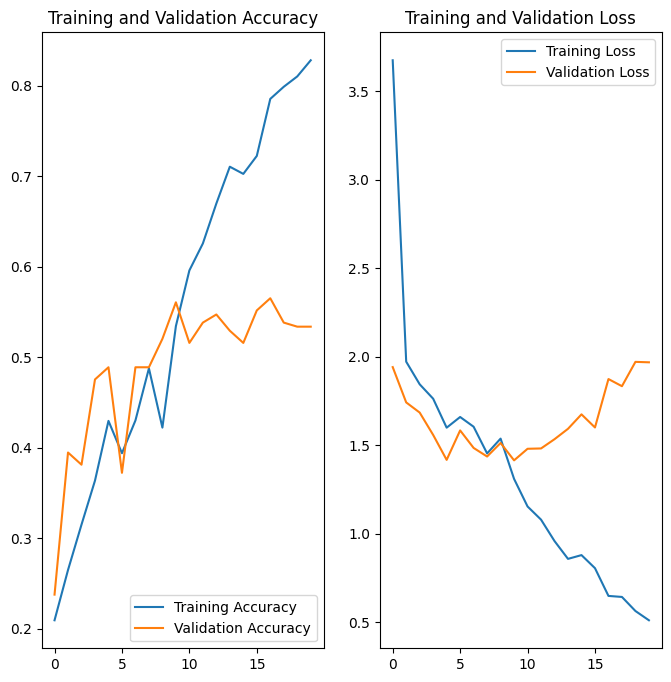

In [141]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Testing of test data

In [143]:
final_test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [144]:
results = model.predict(final_test_ds)

4/4 [==============================] - 2s 118ms/step


In [156]:
results = [np.argmax(i) for i in results]

In [171]:
# tf.Tensor()

In [179]:
labels = []
for i, j in test_ds.enumerate():
    labels.extend(list(j[-1].numpy()))
    # break

len(labels)

118

In [181]:
from sklearn.metrics import accuracy_score

accuracy_score(labels, results)

0.13559322033898305

### Findings - UnderFit
1. Model is not good at all (as it is giving around 53% of training accuracy, and only 13% of test accuracy (if i am calculating it right))
2. Data pre-processing is missing

In [37]:
# Todo, after you have analysed the model fit history for presence of underfit or overfit, choose an appropriate data augumentation strategy. 
# Your code goes here
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.5)
]


def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images



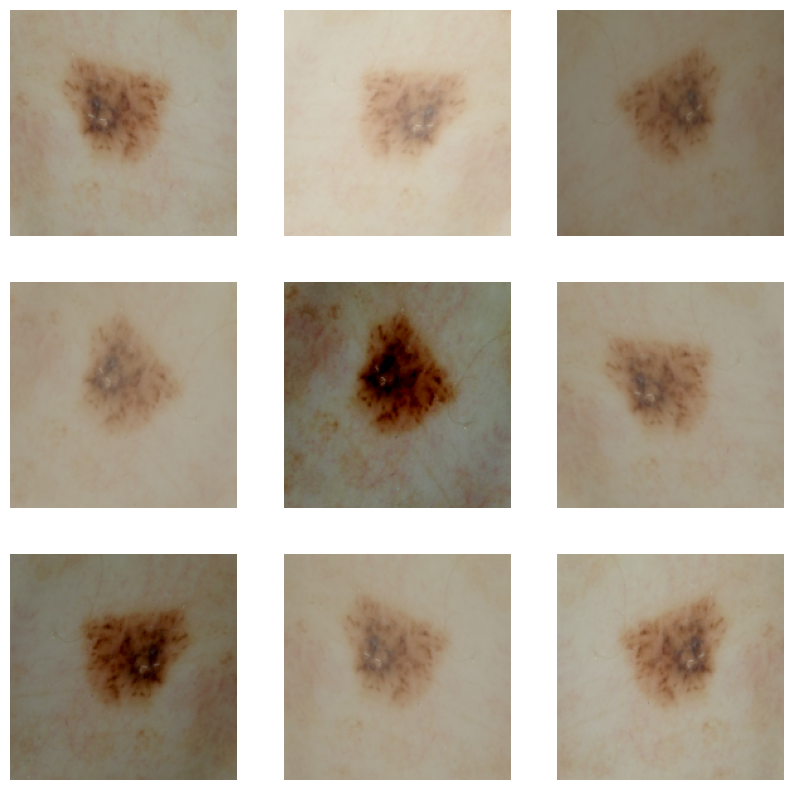

In [38]:
# Todo, visualize how your augmentation strategy works for one instance of training image.
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

### Todo:
### Create the model, compile and train the model


In [39]:
## You can use Dropout layer if there is an evidence of overfitting in your findings

## Your code goes he

augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

augmented_val_ds = val_ds.map(lambda x, y: (data_augmentation(x), y))

# augmented_test_ds = test_ds.map(lambda x, y: (data_augmentation(x), y))



### Compiling the model

In [40]:
### Your code goes here
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

input_shape = (img_height, img_width, 3)
num_classes = len(class_names)

model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape)) # input shape = (img_rows, img_cols, 1)

# second conv layer
model.add(Conv2D(64, kernel_size=(3, 3), 
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# second conv layer
# model.add(Conv2D(128, kernel_size=(3, 3), 
#                  activation='relu'))

# flatten and put a fully connected layer
model.add(Flatten())
model.add(Dense(128, activation='relu')) # fully connected
# model.add(Dropout(0.5))

# model.add(Dense(64, activation='relu')) # fully connected
model.add(Dense(32, activation='relu')) # fully connected

# softmax layer
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])


# model summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 conv2d_3 (Conv2D)           (None, 176, 176, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 88, 88, 64)        0         
 g2D)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 88, 88, 64)        0         
                                                                 
 flatten_1 (Flatten)         (None, 495616)            0         
                                                                 
 dense_3 (Dense)             (None, 128)               63438976  
                                                      

### Training the model

In [ ]:
## Your code goes here, note: train your model for 20 epochs
epochs = 20
history =model.fit(
  augmented_train_ds,
  validation_data=augmented_val_ds,
  epochs=epochs,workers=3, use_multiprocessing=True)

"""
OUTPUT:

Epoch 1/20
63/63 [==============================] - 75s 1s/step - loss: 518.7939 - accuracy: 0.1905 - val_loss: 2.1234 - val_accuracy: 0.2332
Epoch 2/20
63/63 [==============================] - 76s 1s/step - loss: 2.0971 - accuracy: 0.2525 - val_loss: 2.0232 - val_accuracy: 0.2242
Epoch 3/20
63/63 [==============================] - 72s 1s/step - loss: 2.0072 - accuracy: 0.2545 - val_loss: 2.0405 - val_accuracy: 0.2422
Epoch 4/20
63/63 [==============================] - 72s 1s/step - loss: 1.9486 - accuracy: 0.2634 - val_loss: 1.9526 - val_accuracy: 0.2242
Epoch 5/20
63/63 [==============================] - 76s 1s/step - loss: 1.9557 - accuracy: 0.2569 - val_loss: 1.9770 - val_accuracy: 0.2287
Epoch 6/20
63/63 [==============================] - 81s 1s/step - loss: 1.9443 - accuracy: 0.2599 - val_loss: 1.9591 - val_accuracy: 0.2466
Epoch 7/20
63/63 [==============================] - 83s 1s/step - loss: 1.9544 - accuracy: 0.2649 - val_loss: 1.9029 - val_accuracy: 0.2556
Epoch 8/20
63/63 [==============================] - 79s 1s/step - loss: 1.9773 - accuracy: 0.2530 - val_loss: 1.8956 - val_accuracy: 0.2466
Epoch 9/20
63/63 [==============================] - 75s 1s/step - loss: 1.9255 - accuracy: 0.2872 - val_loss: 1.9669 - val_accuracy: 0.2377
Epoch 10/20
63/63 [==============================] - 78s 1s/step - loss: 1.9553 - accuracy: 0.2520 - val_loss: 1.9548 - val_accuracy: 0.2287
Epoch 11/20
38/63 [=================>............] - ETA: 30s - loss: 1.9003 - accuracy: 0.2640

<Keyboard Interrupt>
"""

### Visualizing the results

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Findings:
Model accuracy hasn't improved that much with data augmentation. Though there is a slight improvement in the accuracy by adding some augmentation layer

#### - Which class has the least number of samples? - 
seborrheic keratosis

#### - Which classes dominate the data in terms proportionate number of samples?
pigmented benign keratosis


<br>

#### Using `Augmentor` for handling class imbalance problem

In [207]:
# !pip install Augmentor

To use `Augmentor`, the following general procedure is followed:

1. Instantiate a `Pipeline` object pointing to a directory containing your initial image data set.<br>
2. Define a number of operations to perform on this data set using your `Pipeline` object.<br>
3. Execute these operations by calling the `Pipeline’s` `sample()` method.


In [209]:
path_to_training_dataset=train_path
import Augmentor
for i in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + i)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.random_contrast(probability=0.7, min_factor=0.2, max_factor=0.6)
    p.sample(500) ## We are adding 500 samples per class to make sure that none of the classes are sparse.

Initialised with 114 image(s) found.
Output directory set to C:/Users/Joseph/PycharmProjects/upGrad/CNN/MelonnaAssignment/Skin cancer ISIC The International Skin Imaging Collaboration//Train/actinic keratosis\output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x11F8A8CF910>: 100%|██████████| 500/500 [00:01<00:00, 264.41 Samples/s]


Initialised with 376 image(s) found.
Output directory set to C:/Users/Joseph/PycharmProjects/upGrad/CNN/MelonnaAssignment/Skin cancer ISIC The International Skin Imaging Collaboration//Train/basal cell carcinoma\output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x11F8AC13370>: 100%|██████████| 500/500 [00:01<00:00, 265.57 Samples/s]                  


Initialised with 95 image(s) found.
Output directory set to C:/Users/Joseph/PycharmProjects/upGrad/CNN/MelonnaAssignment/Skin cancer ISIC The International Skin Imaging Collaboration//Train/dermatofibroma\output.

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x11F8EB52250>: 100%|██████████| 500/500 [00:03<00:00, 129.87 Samples/s]                  


Initialised with 181 image(s) found.
Output directory set to C:/Users/Joseph/PycharmProjects/upGrad/CNN/MelonnaAssignment/Skin cancer ISIC The International Skin Imaging Collaboration//Train/squamous cell carcinoma\output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x11F8A580580>: 100%|██████████| 500/500 [00:01<00:00, 273.96 Samples/s]                  


Initialised with 139 image(s) found.
Output directory set to C:/Users/Joseph/PycharmProjects/upGrad/CNN/MelonnaAssignment/Skin cancer ISIC The International Skin Imaging Collaboration//Train/vascular lesion\output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x11F8EB2C160>: 100%|██████████| 500/500 [00:01<00:00, 268.05 Samples/s]                  


Augmentor has stored the augmented images in the output sub-directory of each of the sub-directories of skin cancer types.. Lets take a look at total count of augmented images.

In [210]:
image_count_train = len(list(data_dir_train.glob('*/output/*.jpg')))
print(image_count_train)

9000


### Lets see the distribution of augmented data after adding new images to the original training data.

In [43]:
from glob import glob

path_list = [x for x in glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]
path_list

['C:\\Users\\Joseph\\PycharmProjects\\upGrad\\CNN\\MelonnaAssignment\\Skin cancer ISIC The International Skin Imaging Collaboration\\Train\\actinic keratosis\\output\\actinic keratosis_original_ISIC_0025780.jpg_0b4e3bca-5179-47ae-82cb-fd659062dba5.jpg',
 'C:\\Users\\Joseph\\PycharmProjects\\upGrad\\CNN\\MelonnaAssignment\\Skin cancer ISIC The International Skin Imaging Collaboration\\Train\\actinic keratosis\\output\\actinic keratosis_original_ISIC_0025780.jpg_2a142b54-f5a0-416f-ad41-117c53567442.jpg',
 'C:\\Users\\Joseph\\PycharmProjects\\upGrad\\CNN\\MelonnaAssignment\\Skin cancer ISIC The International Skin Imaging Collaboration\\Train\\actinic keratosis\\output\\actinic keratosis_original_ISIC_0025780.jpg_5495cd27-8eac-4a21-804c-a1f9d0ebba9e.jpg',
 'C:\\Users\\Joseph\\PycharmProjects\\upGrad\\CNN\\MelonnaAssignment\\Skin cancer ISIC The International Skin Imaging Collaboration\\Train\\actinic keratosis\\output\\actinic keratosis_original_ISIC_0025780.jpg_5aeb5739-b1ed-453a-99f5-7f0

In [46]:
lesion_list_new = [os.path.basename(os.path.dirname(os.path.dirname(y))) for y in glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]
lesion_list_new[:5]

['actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis']

In [215]:
dataframe_dict_new = dict(zip(path_list, lesion_list_new))

In [231]:
# del final_train_ds
# del final_val_ds

In [237]:
df2 = pd.DataFrame(list(dataframe_dict_new.items()),columns = ['Path','Label'])
# new_df = original_df.append(df2)
df2.head()

,Path,Label
0,C:\Users\Joseph\PycharmProjects\upGrad\CNN\Mel...,actinic keratosis
1,C:\Users\Joseph\PycharmProjects\upGrad\CNN\Mel...,actinic keratosis
2,C:\Users\Joseph\PycharmProjects\upGrad\CNN\Mel...,actinic keratosis
3,C:\Users\Joseph\PycharmProjects\upGrad\CNN\Mel...,actinic keratosis
4,C:\Users\Joseph\PycharmProjects\upGrad\CNN\Mel...,actinic keratosis


In [239]:
df2['Label'].value_counts()

Label
actinic keratosis             1000
basal cell carcinoma          1000
dermatofibroma                1000
melanoma                      1000
nevus                         1000
pigmented benign keratosis    1000
seborrheic keratosis          1000
squamous cell carcinoma       1000
vascular lesion               1000
Name: count, dtype: int64

So, now we have added 500 images to all the classes to maintain some class balance. We can add more images as we want to improve training process.

#### **Todo**: Train the model on the data created using Augmentor

In [240]:
batch_size = 32
img_height = 180
img_width = 180

#### **Todo:** Create a training dataset

In [245]:
data_dir_train=train_path
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  seed=123,
  validation_split = 0.2,
  subset = "both",
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 11239 files belonging to 9 classes.
Using 8992 files for training.
Using 2247 files for validation.


#### **Todo:** Create a validation dataset

In [246]:
# val_ds = tf.keras.preprocessing.image_dataset_from_directory(
#   data_dir_train,
#   seed=123,
#   validation_split = 0.2,
#   subset = ## Todo choose the correct parameter value, so that only validation data is refered to,
#   image_size=(img_height, img_width),
#   batch_size=batch_size)

#### **Todo:** Create your model (make sure to include normalization)

In [247]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Apply Rescaling
normalization_layer = tf.keras.layers.experimental.preprocessing.Rescaling(1./255)
final_train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
# final_train_ds = next(iter(normalized_training_set))

final_val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [47]:
## your code goes here
### Your code goes here
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

input_shape = (img_height, img_width, 3)
num_classes = len(class_names)

model = Sequential()


model.add(layers.experimental.preprocessing.Rescaling(1./255,input_shape=(180,180,3))) #Rescaling Layer

model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape)) # input shape = (img_rows, img_cols, 1)

# second conv layer
model.add(Conv2D(64, kernel_size=(3, 3), 
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# second conv layer
model.add(Conv2D(128, kernel_size=(3, 3), 
                 activation='relu'))

# flatten and put a fully connected layer
model.add(Flatten())
model.add(Dense(128, activation='relu')) # fully connected
# model.add(Dropout(0.5))

# model.add(Dense(64, activation='relu')) # fully connected
model.add(Dense(32, activation='relu')) # fully connected

# softmax layer
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])


# model summary
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 conv2d_5 (Conv2D)           (None, 176, 176, 64)      18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 88, 88, 64)        0         
 g2D)                                                            
                                                                 
 dropout_3 (Dropout)         (None, 88, 88, 64)        0         
                                                                 
 conv2d_6 (Conv2D)           (None, 86, 86, 128)       73856     
                                                      

#### **Todo:** Compile your model (Choose optimizer and loss function appropriately)

In [48]:
## your code goes here
## Your code goes here, note: train your model for 20 epochs
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])


# model summary
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 conv2d_5 (Conv2D)           (None, 176, 176, 64)      18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 88, 88, 64)        0         
 g2D)                                                            
                                                                 
 dropout_3 (Dropout)         (None, 88, 88, 64)        0         
                                                                 
 conv2d_6 (Conv2D)           (None, 86, 86, 128)       73856     
                                                      

#### **Todo:**  Train your model

In [251]:
epochs = 30
history =model.fit(
  final_train_ds,
  validation_data=final_val_ds,
  epochs=epochs,workers=10, use_multiprocessing=True)

Epoch 1/30
281/281 [==============================] - 342s 1s/step - loss: 2.4508 - accuracy: 0.2539 - val_loss: 1.7676 - val_accuracy: 0.3511
Epoch 2/30
281/281 [==============================] - 325s 1s/step - loss: 1.5327 - accuracy: 0.4277 - val_loss: 1.4045 - val_accuracy: 0.4878
Epoch 3/30
281/281 [==============================] - 318s 1s/step - loss: 1.2632 - accuracy: 0.5447 - val_loss: 1.3453 - val_accuracy: 0.4895
Epoch 4/30
281/281 [==============================] - 318s 1s/step - loss: 0.9527 - accuracy: 0.6712 - val_loss: 0.9974 - val_accuracy: 0.6680
Epoch 5/30
281/281 [==============================] - 318s 1s/step - loss: 0.7684 - accuracy: 0.7335 - val_loss: 1.1163 - val_accuracy: 0.6431
Epoch 6/30
281/281 [==============================] - 315s 1s/step - loss: 0.6190 - accuracy: 0.7920 - val_loss: 1.0334 - val_accuracy: 0.6707
Epoch 7/30
281/281 [==============================] - 316s 1s/step - loss: 0.5102 - accuracy: 0.8326 - val_loss: 1.0456 - val_accuracy: 0.6836

#### **Todo:**  Visualize the model results

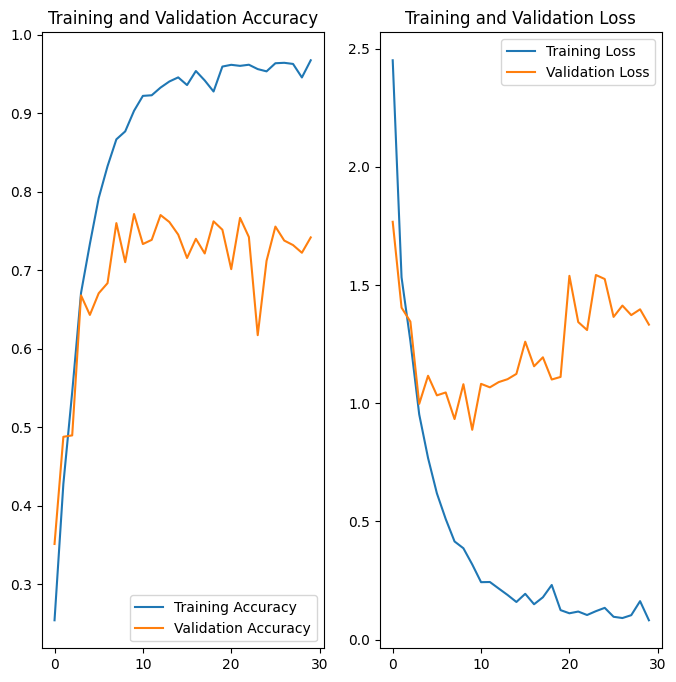

In [252]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Did you get rid of underfitting/overfitting? Did class rebalance help?
The model is still somewhat overfitting, because there is a noticeable gap in validation and training loss. 
Having said that, the model has improved a lot by handling `class imabalance` and using `data augmentation` tehniques.
